In [ ]:
def svd_image_compress(image_path, k=50):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image

    def svd_compress_channel(channel, k):
        U, S, VT = np.linalg.svd(channel, full_matrices=False)
        return np.dot(U[:, :k], np.dot(np.diag(S[:k]), VT[:k, :]))

    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    compressed = np.zeros_like(img_array)
    for i in range(3):  # R, G, B
        compressed[:, :, i] = np.clip(svd_compress_channel(img_array[:, :, i], k), 0, 255)

    compressed_img = compressed.astype(np.uint8)

    # Show result
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(compressed_img)
    plt.title(f"SVD Compressed (k={k})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Save compressed image
    output_path = image_path.rsplit('.', 1)[0] + '_compressed.jpg'
    Image.fromarray(compressed_img).save(output_path)

    return compressed_img


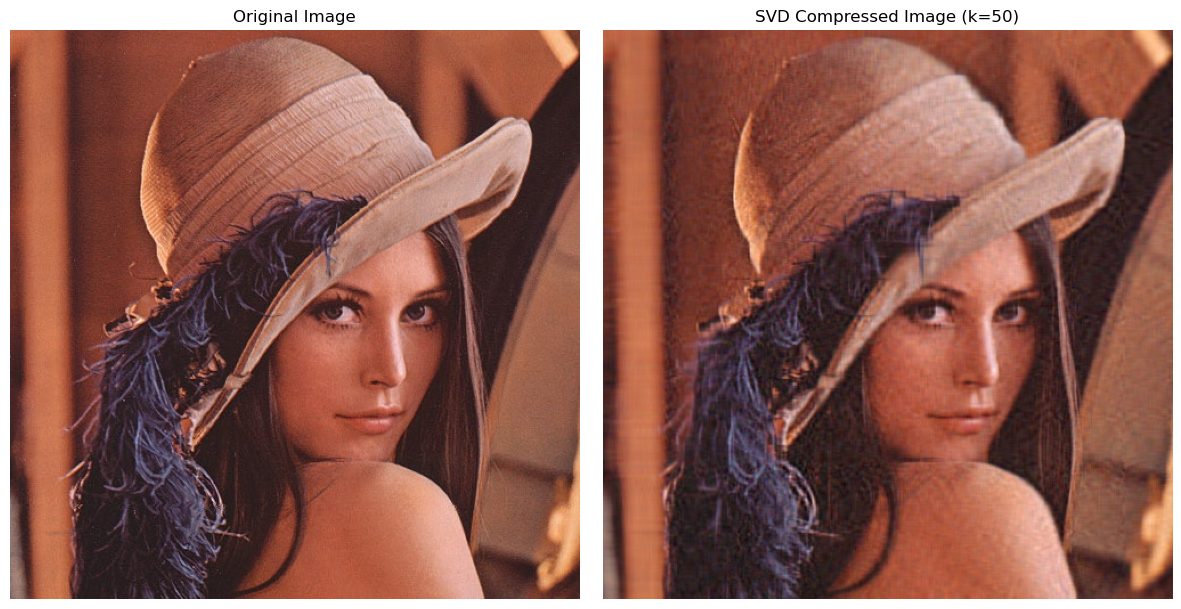

✅ Compressed image saved to: compressed_lenna.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def svd_compress_channel(channel, k):
    """
    對單一色彩通道進行 SVD 壓縮
    """
    U, S, VT = np.linalg.svd(channel, full_matrices=False)
    S_k = np.diag(S[:k])
    U_k = U[:, :k]
    VT_k = VT[:k, :]
    compressed = np.dot(U_k, np.dot(S_k, VT_k))
    return np.clip(compressed, 0, 255)

def svd_image_compress(image_path, k=50, save_path=None):
    """
    對 RGB 彩色圖像進行 SVD 壓縮
    - image_path: 圖像檔案路徑
    - k: 保留的奇異值個數
    - save_path: 若給定，將儲存壓縮圖像
    """
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    compressed_img = np.zeros_like(img_array, dtype=np.uint8)

    for i in range(3):  # 對 R, G, B 三通道各自壓縮
        compressed_channel = svd_compress_channel(img_array[:, :, i], k)
        compressed_img[:, :, i] = compressed_channel.astype(np.uint8)

    # 顯示原圖與壓縮後圖像
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_array)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(compressed_img)
    axes[1].set_title(f"SVD Compressed Image (k={k})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    # 儲存圖像
    if save_path:
        Image.fromarray(compressed_img).save(save_path)
        print(f"✅ Compressed image saved to: {save_path}")

    return compressed_img

# 📌 範例使用：壓縮 Lenna.png 並儲存
compressed = svd_image_compress("Lenna.png", k=50, save_path="compressed_lenna.png")
